In [2]:
%load_ext autoreload
%autoreload 2
import os
import sys

In [3]:
import pangaeapy.pandataset as pds
import json
import pandas as pd
import requests
from tqdm import tqdm
import time

from dotenv import load_dotenv
load_dotenv()
REPO = os.getenv("REPO_PATH")

In [ ]:
folder_ds = os.path.join(REPO, 'outputs/pangaea')
fn_ds = 'sample_20260629_163144.json'
fp_ds = os.path.join(folder_ds, fn_ds)

with open(fp_ds, 'r') as f:
    ds_sampled = json.load(f)

def get_id_from_doi(doi: str) -> str:
    """Extract the ID from a DOI string."""
    return doi.split('/')[-1].strip('PANGAEA.')

ds_sampled

{'by_topic': {'Agriculture': ['doi:10.1594/PANGAEA.990157',
   'doi:10.1594/PANGAEA.990159',
   'doi:10.1594/PANGAEA.964635',
   'doi:10.1594/PANGAEA.943160',
   'doi:10.1594/PANGAEA.974754',
   'doi:10.1594/PANGAEA.974037',
   'doi:10.1594/PANGAEA.945395',
   'doi:10.1594/PANGAEA.982395',
   'doi:10.1594/PANGAEA.990164',
   'doi:10.1594/PANGAEA.990160'],
  'Atmosphere': ['doi:10.1594/PANGAEA.913868',
   'doi:10.1594/PANGAEA.893188',
   'doi:10.1594/PANGAEA.990495',
   'doi:10.1594/PANGAEA.939047',
   'doi:10.1594/PANGAEA.913861',
   'doi:10.1594/PANGAEA.925555',
   'doi:10.1594/PANGAEA.945294',
   'doi:10.1594/PANGAEA.905663',
   'doi:10.1594/PANGAEA.927062',
   'doi:10.1594/PANGAEA.969067'],
  'Biological Classification': ['doi:10.1594/PANGAEA.928506',
   'doi:10.1594/PANGAEA.965137',
   'doi:10.1594/PANGAEA.920951',
   'doi:10.1594/PANGAEA.925913',
   'doi:10.1594/PANGAEA.935404',
   'doi:10.1594/PANGAEA.965135',
   'doi:10.1594/PANGAEA.974800',
   'doi:10.1594/PANGAEA.983295',
   '

In [28]:
dict_info = {x: [] for x in ['name', 'description', 'keywords', 'license', 'n_rows', 'n_columns', 'topic', 'doi', 'id']}

for topic, dois in ds_sampled['by_topic'].items():
    print(f"Topic: {topic}, Number of DOIs: {len(dois)}")
    for doi in dois:
        id_ = get_id_from_doi(doi)
        # print(f"DOI: {doi}, ID: {id_}")
        ds = pds.PanDataSet(id_)

        ds_metadata = {
            'name': ds.title,
            'description': ds.abstract,
            'keywords': ds.keywords,
            'license': ds.licence.name,
            'n_rows': len(ds.data),
            'n_columns': len(ds.data.columns)

        }

        for key, value in ds_metadata.items():
            dict_info[key].append(value)
        dict_info['topic'].append(topic)
        dict_info['doi'].append(doi)
        dict_info['id'].append(id_)

df_info = pd.DataFrame(dict_info)

Topic: Agriculture, Number of DOIs: 10


Data set is protected - 
Dataset is either restricted or of type "collection" - https://doi.pangaea.de/10.1594/PANGAEA.974754
Data access failed, no tabular data available - https://doi.org/10.1594/PANGAEA.945395


Topic: Atmosphere, Number of DOIs: 10


Data set is of type collection, please select one of its child datasets - 
Dataset is either restricted or of type "collection" - https://doi.org/10.1594/PANGAEA.893188


Topic: Biological Classification, Number of DOIs: 11
Topic: Biosphere, Number of DOIs: 11
Topic: Chemistry, Number of DOIs: 11
Topic: Cryosphere, Number of DOIs: 10
Topic: Ecology, Number of DOIs: 11


...

Data access failed, no tabular data available - https://doi.org/10.1594/PANGAEA.933913
Data set is protected - 


Topic: Lithosphere, Number of DOIs: 11


Dataset is either restricted or of type "collection" - https://doi.pangaea.de/10.1594/PANGAEA.993253


Topic: Oceans, Number of DOIs: 11
Topic: Paleontology, Number of DOIs: 11


Data set is protected - 
Dataset is either restricted or of type "collection" - https://doi.pangaea.de/10.1594/PANGAEA.979885


In [38]:
df_info.license.value_counts()

license
Creative Commons Attribution 4.0 International                  150
Creative Commons Attribution 3.0 Unported                         7
Creative Commons Attribution-NoDerivs 4.0 International           1
Creative Commons Attribution-NonCommercial 4.0 International      1
Creative Commons Attribution-ShareAlike 4.0 International         1
Name: count, dtype: int64

Filtered datasets by license. Remaining datasets: 150/160
Removed licenses:
license
Creative Commons Attribution 3.0 Unported                       7
Creative Commons Attribution-NoDerivs 4.0 International         1
Creative Commons Attribution-NonCommercial 4.0 International    1
Creative Commons Attribution-ShareAlike 4.0 International       1
Name: count, dtype: int64
Removed datasets with less than 2 rows. Remaining datasets: 136/150


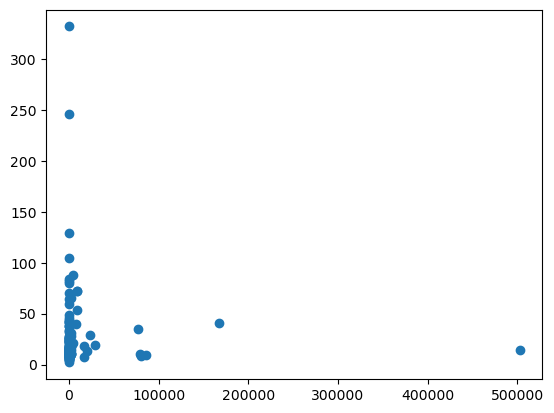

In [43]:
def filter_df_ds(df):
    licenses_keep = ['Creative Commons Attribution 4.0 International']
    count_prev = len(df)
    df = df[df['license'].isin(licenses_keep)]
    count_after = len(df)
    print(f"Filtered datasets by license. Remaining datasets: {count_after}/{count_prev}")
    licenses_removed = df_info[~df_info['license'].isin(licenses_keep)]['license'].value_counts()
    print(f"Removed licenses:\n{licenses_removed}")

    min_rows = 2 
    df = df[df['n_rows'] >= min_rows]
    count_prev = len(df)
    print(f"Removed datasets with less than {min_rows} rows. Remaining datasets: {count_prev}/{count_after}")

    df['n_elements'] = df['n_rows'] * df['n_columns']

    return df

df_filtered = filter_df_ds(df_info)

import matplotlib.pyplot as plt

plt.plot(df_filtered['n_rows'], df_filtered['n_columns'], 'o')

In [57]:
df_info[df_info['topic'] == 'Atmosphere']

,name,description,keywords,license,n_rows,n_columns,topic,doi,id
10,Aerosol size distribution between 90 and 5000 ...,The aerosol size distribution between 90 and 5...,"[aerosol, Antarctica, Neumayer Station, size d...",Creative Commons Attribution 4.0 International,8754,72,Atmosphere,doi:10.1594/PANGAEA.913868,913868
11,Integrated water vapor and temperature profile...,In the frame of the OASIS-YOPP project measure...,[Atmosphere],Creative Commons Attribution 3.0 Unported,0,0,Atmosphere,doi:10.1594/PANGAEA.893188,893188
12,Ultrasonic anemometer on-board wind measuremen...,This dataset consists of wind measurements tak...,"[Arctic, Atmosphere, Polarstern, wind]",Creative Commons Attribution 4.0 International,502615,14,Atmosphere,doi:10.1594/PANGAEA.990495,990495
13,Continuous surface water vapour isotope monito...,This dataset presents the first fully continuo...,"[Antarctica, Continuous isotope monitoring, Pa...",Creative Commons Attribution 4.0 International,17133,18,Atmosphere,doi:10.1594/PANGAEA.939047,939047
14,Aerosol size distribution between 90 and 5000 ...,The aerosol size distribution between 90 and 5...,"[aerosol, Antarctica, size distribution, Spuso]",Creative Commons Attribution 4.0 International,8518,72,Atmosphere,doi:10.1594/PANGAEA.913861,913861
15,Condensation nuclei >3 nm (CN3) measurements a...,Measurements of condensation nuclei greater th...,"[aerosol, biomass burning, CN3, COALA-2020, ne...",Creative Commons Attribution 4.0 International,79941,8,Atmosphere,doi:10.1594/PANGAEA.925555,925555
16,Atmospheric air pressure from Central-western ...,The meteorological database provided herein de...,"[air temperature, Antarctica, Criosfera 1]",Creative Commons Attribution 4.0 International,86307,9,Atmosphere,doi:10.1594/PANGAEA.945294,945294
17,Navopatía Flux Station eddy covariance (EC) da...,Objective:\n-----\nThe objective of this datab...,"[Carbon, latent heat, mangrove, Navopatía, sen...",Creative Commons Attribution-NoDerivs 4.0 Inte...,24079,11,Atmosphere,doi:10.1594/PANGAEA.905663,905663
18,Tethered balloon-borne meteorological measurem...,The tethered balloon system BELUGA (Balloon-bo...,"[ABL, AO2018(MOCCHA), High Arctic, radiation, ...",Creative Commons Attribution 4.0 International,1801,10,Atmosphere,doi:10.1594/PANGAEA.927062,927062
19,Daily meteorological data from automatic weath...,Presented dataset contains meteorological data...,"[automatic weather station, meteorology of pol...",Creative Commons Attribution 4.0 International,2191,17,Atmosphere,doi:10.1594/PANGAEA.969067,969067


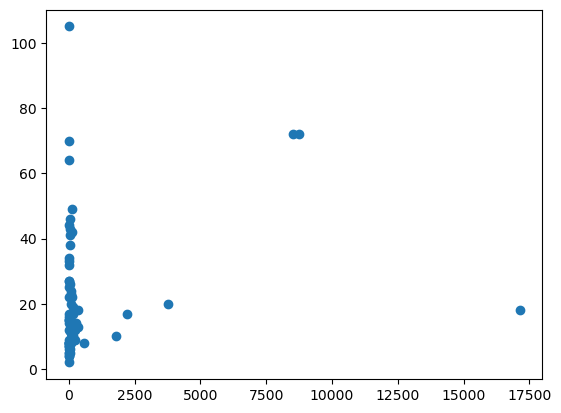

In [59]:
n_datasets_per_topic = 5
## get the top n datasets per topic based on the number of elements (rows * columns)
df_filtered_sorted = df_filtered.sort_values(by='n_elements', ascending=True)
df_top_n_per_topic = df_filtered_sorted.groupby('topic').head(n_datasets_per_topic)
df_top_n_per_topic.reset_index(drop=True, inplace=True)
# df_top_n_per_topic.
plt.plot(df_top_n_per_topic['n_rows'], df_top_n_per_topic['n_columns'], 'o')
# df_filtered_sorted

In [ ]:
df_top_n_per_topic


In [73]:
list_citations = []
list_keys = []

def get_bibtex(doi: str) -> str:
    url = f"https://doi.pangaea.de/{doi}"
    r = requests.get(url, headers={"Accept": "application/x-bibtex"})
    r.raise_for_status()
    return r.text

for row in tqdm(df_top_n_per_topic.itertuples()):
    ds = pds.PanDataSet(row.id)
    data = ds.data
    data.to_csv(os.path.join(folder_ds, 'pangaea_datasets', f"{row.id}.csv"), index=False)

    citation = get_bibtex(row.doi)
    key = citation.split('{')[1].split(',')[0]
    list_citations.append(citation)
    list_keys.append(key)

    time.sleep(0.2)  # To avoid overwhelming the server with requests

df_top_n_per_topic['citation_key'] = list_keys

df_top_n_per_topic.to_csv(os.path.join(folder_ds, 'sample_20260629_163144_filtered_top5_per_topic.csv'), index=False)
## save citations to a text file
with open(os.path.join(folder_ds, 'pangaea_datasets', 'sample_20260629_163144_filtered_top5_citations.bib'), 'w') as f:
    f.write('\n\n'.join(list_citations))

5it [00:03,  1.47it/s]Could not create QC flag dataframe - https://doi.org/10.1594/PANGAEA.954529
75it [00:57,  1.31it/s]
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_96229/948854408.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_n_per_topic['citation_key'] = list_keys


In [74]:
df_top_n_per_topic

,name,description,keywords,license,n_rows,n_columns,topic,doi,id,n_elements,citation_key
0,A regional pCO2 climatology of the Baltic Sea,Based on direct surface pCO2 observation and a...,"[Baltic Sea, climatology, CO2]",Creative Commons Attribution 4.0 International,2,4,Lithosphere,doi:10.1594/PANGAEA.961119,961119,8,bittig2023arpc
1,Underwater video recordings during mesopelagic...,During three cruises in the Mid Atlantic Ridge...,"[mesopelagic fish, mesopelagic invertebrates]",Creative Commons Attribution 4.0 International,2,7,Fisheries,doi:10.1594/PANGAEA.931902,931902,14,grimaldo2021uvrd
2,Involving local communities for effective citi...,These three datasets are related to the analys...,"[bushmeat, Citizen science, community-based mo...",Creative Commons Attribution 4.0 International,3,5,Lakes & Rivers,doi:10.1594/PANGAEA.906209,906209,15,elbizri2019ilcf
3,Raw data from Pure-rotational and Vibro-rotati...,The data correspond to measurements along a ve...,"[Experiment, extinction retrieval, pure-rotati...",Creative Commons Attribution 4.0 International,2,8,Human Dimensions,doi:10.1594/PANGAEA.931282,931282,16,zentenohernndez2021rdfp
4,"Ground Temperature Map, 2000-2017, Antarctic",The product provides modeled mean annual groun...,"[Antarctic, Cryosphere, ground temperatures, P...",Creative Commons Attribution 4.0 International,4,5,Cryosphere,doi:10.1594/PANGAEA.902576,902576,20,obu2019gtma
...,...,...,...,...,...,...,...,...,...,...,...
70,Daily meteorological data from automatic weath...,Presented dataset contains meteorological data...,"[automatic weather station, meteorology of pol...",Creative Commons Attribution 4.0 International,2191,17,Atmosphere,doi:10.1594/PANGAEA.969067,969067,37247,plenzler2024dmdf
71,A compilation of published pyrite sulfur isoto...,This dataset contains a compilation of the sul...,"[AGE, Depth, Lithology, Methane, pyrite, sedim...",Creative Commons Attribution 4.0 International,3754,20,Geophysics,doi:10.1594/PANGAEA.972993,972993,75080,spruzen2024acop
72,Continuous surface water vapour isotope monito...,This dataset presents the first fully continuo...,"[Antarctica, Continuous isotope monitoring, Pa...",Creative Commons Attribution 4.0 International,17133,18,Atmosphere,doi:10.1594/PANGAEA.939047,939047,308394,bagheridastgerdi2021cswv
73,Aerosol size distribution between 90 and 5000 ...,The aerosol size distribution between 90 and 5...,"[aerosol, Antarctica, size distribution, Spuso]",Creative Commons Attribution 4.0 International,8518,72,Atmosphere,doi:10.1594/PANGAEA.913861,913861,613296,weller2020asdb
